In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ecommerce.csv")
df.head()

,order_id,customer_id,order_date,product_category,product_name,price,quantity,payment_method,country,shipping_time_days,returned
0,1001,C001,2025-01-05,Electronics,Wireless Mouse,25.99,2,Credit Card,Germany,3,No
1,1002,C002,2025-01-07,Clothing,T-Shirt,15.00,1,PayPal,Germany,5,No
2,1003,C003,2025-01-08,Electronics,Headphones,79.99,1,Credit Card,France,4,Yes
3,1004,C001,2025-01-10,Home,Blender,49.99,1,Klarna,Germany,6,No
4,1005,C004,2025-01-11,Clothing,Jeans,60.00,1,PayPal,Spain,7,Yes


In [3]:
df.describe()

,order_id,price,quantity,shipping_time_days
count,20.00000,20.000000,20.00000,20.000000
mean,1010.50000,174.422500,1.25000,4.450000
std,5.91608,246.936617,0.55012,1.571958
min,1001.00000,15.000000,1.00000,2.000000
25%,1005.75000,45.375000,1.00000,3.000000
50%,1010.50000,87.495000,1.00000,4.500000
75%,1015.25000,162.497500,1.00000,6.000000
max,1020.00000,999.000000,3.00000,7.000000


## 1. Grundlegende Exploration (EDA)
### Wie hoch ist der Gesamtumsatz?



In [4]:
df1 = df
df1 = df1[df1["returned"] == "No"]

In [5]:
df1["sum_price"] = (df1["price"] * df1["quantity"])
df1.head()

C:\Users\Sunsonella\AppData\Local\Temp\ipykernel_8932\3997115774.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["sum_price"] = (df1["price"] * df1["quantity"])


,order_id,customer_id,order_date,product_category,product_name,price,quantity,payment_method,country,shipping_time_days,returned,sum_price
0,1001,C001,2025-01-05,Electronics,Wireless Mouse,25.99,2,Credit Card,Germany,3,No,51.98
1,1002,C002,2025-01-07,Clothing,T-Shirt,15.00,1,PayPal,Germany,5,No,15.00
3,1004,C001,2025-01-10,Home,Blender,49.99,1,Klarna,Germany,6,No,49.99
5,1006,C005,2025-01-12,Electronics,Keyboard,45.50,1,Credit Card,Germany,3,No,45.50
6,1007,C006,2025-01-15,Home,Coffee Maker,89.99,1,Credit Card,Italy,5,No,89.99


In [6]:
total_price = df1["sum_price"].sum()
print(total_price)

3014.46


### Welche Produktkategorie generiert den meisten Umsatz?

In [7]:
df1.groupby("product_category").agg({
    "sum_price": "sum" 
})

,sum_price
product_category,
Clothing,370.00
Electronics,2314.48
Home,329.98



### Wie viele Bestellungen pro Land gibt es?

In [8]:
df1.groupby("country")["order_id"].count()

country
France      1
Germany    11
Italy       1
Spain       2
Name: order_id, dtype: int64

## 2. Kundenanalyse
### Wer sind die Top-Kunden nach Umsatz?



In [9]:
df1.groupby("customer_id").agg({
    "sum_price": "sum" 
})

,sum_price
customer_id,
C001,321.97
C002,135.00
C003,299.00
C004,120.00
C005,45.50
C006,89.99
C007,699.00
C009,85.00
C010,70.00


### Wie oft bestellen wiederkehrende Kunden (z. B. C001)?

In [10]:
df1.groupby("customer_id")["order_id"].count()

customer_id
C001    3
C002    2
C003    1
C004    1
C005    1
C006    1
C007    1
C009    1
C010    1
C011    1
C013    1
C014    1
Name: order_id, dtype: int64

### Gibt es Hinweise auf Customer Lifetime Value (CLV)?

In [11]:
clv = df1.groupby("customer_id").agg({
    "order_id": "nunique",
    "sum_price": "sum"
})

clv["avg_order_value"] = clv["sum_price"] / clv["order_id"]
clv.head(20)

,order_id,sum_price,avg_order_value
customer_id,,,
C001,3,321.97,107.323333
C002,2,135.00,67.500000
C003,1,299.00,299.000000
C004,1,120.00,120.000000
C005,1,45.50,45.500000
C006,1,89.99,89.990000
C007,1,699.00,699.000000
C009,1,85.00,85.000000
C010,1,70.00,70.000000


CLV pro Land

In [12]:
df1.groupby("country").apply(lambda x: x.groupby("customer_id")["sum_price"].sum().mean())

country
France     299.00000
Germany    304.43375
Italy       89.99000
Spain       95.00000
dtype: float64

CLV Top Kunden

In [13]:
df1.groupby("customer_id")["sum_price"].sum().sort_values(ascending=False)

customer_id
C014    999.00
C007    699.00
C001    321.97
C003    299.00
C002    135.00
C004    120.00
C013     90.00
C006     89.99
C009     85.00
C010     70.00
C011     60.00
C005     45.50
Name: sum_price, dtype: float64

## 3. Produktanalyse
### Welche Produkte werden am häufigsten verkauft (nach Menge)?



In [14]:
df.head()

,order_id,customer_id,order_date,product_category,product_name,price,quantity,payment_method,country,shipping_time_days,returned
0,1001,C001,2025-01-05,Electronics,Wireless Mouse,25.99,2,Credit Card,Germany,3,No
1,1002,C002,2025-01-07,Clothing,T-Shirt,15.00,1,PayPal,Germany,5,No
2,1003,C003,2025-01-08,Electronics,Headphones,79.99,1,Credit Card,France,4,Yes
3,1004,C001,2025-01-10,Home,Blender,49.99,1,Klarna,Germany,6,No
4,1005,C004,2025-01-11,Clothing,Jeans,60.00,1,PayPal,Spain,7,Yes


In [15]:
df1.groupby("product_name").agg({
    "quantity": "sum" 
}).sort_values(by="quantity", ascending=False)

,quantity
product_name,
Hat,3
Sweater,2
Toaster,2
Wireless Mouse,2
Air Fryer,1
Blender,1
Coffee Maker,1
Jacket,1
Keyboard,1


### Welche Produkte bringen den meisten Umsatz?

In [16]:
df1.groupby("product_name").agg({
    "quantity": "sum" ,
    "sum_price": "sum" 
}).sort_values(by="quantity", ascending=False)

,quantity,sum_price
product_name,,
Hat,3,60.00
Sweater,2,90.00
Toaster,2,70.00
Wireless Mouse,2,51.98
Air Fryer,1,120.00
Blender,1,49.99
Coffee Maker,1,89.99
Jacket,1,85.00
Keyboard,1,45.50


### Gibt es teure Produkte mit niedriger Nachfrage?

Kleiner Datensatz, Laptop und Smartphone

## 4. Retouren-Analyse
### Wie hoch ist die Retourenquote insgesamt?

In [17]:
df2 = df
df2.head()

,order_id,customer_id,order_date,product_category,product_name,price,quantity,payment_method,country,shipping_time_days,returned
0,1001,C001,2025-01-05,Electronics,Wireless Mouse,25.99,2,Credit Card,Germany,3,No
1,1002,C002,2025-01-07,Clothing,T-Shirt,15.00,1,PayPal,Germany,5,No
2,1003,C003,2025-01-08,Electronics,Headphones,79.99,1,Credit Card,France,4,Yes
3,1004,C001,2025-01-10,Home,Blender,49.99,1,Klarna,Germany,6,No
4,1005,C004,2025-01-11,Clothing,Jeans,60.00,1,PayPal,Spain,7,Yes


In [18]:
df2.groupby("returned")["customer_id"].count()

returned
No     15
Yes     5
Name: customer_id, dtype: int64

In [ ]:
# retourenquote berechnen

returns = df2["returned"].value_counts()

return_rate = returns["Yes"] / (returns["Yes"] + returns["No"])
print(return_rate)

0.25


### Welche Kategorie hat die meisten Rücksendungen?

In [ ]:
# Retourenrate pro Produkt berechnen

product_returns = df2.groupby("product_category")["returned"].apply(
    lambda x: (x == "Yes").mean()
)

In [ ]:
# sortieren nach höchster retourenrate (oben problematisch)

product_returns.sort_values(ascending=False)

product_category
Home           0.333333
Electronics    0.250000
Clothing       0.166667
Name: returned, dtype: float64

In [ ]:
# Mit Anzahl an Bestellungen kombinieren

analysis = df2.groupby("product_category").agg({
    "returned": lambda x: (x == "Yes").mean(),
    "order_id": "count"
})

analysis = analysis.rename(columns={
    "returned": "return_rate",
    "order_id": "num_orders"
})

analysis.sort_values("return_rate", ascending=False)

,return_rate,num_orders
product_category,,
Home,0.333333,6
Electronics,0.250000,8
Clothing,0.166667,6


### Gibt es einen Zusammenhang zwischen Preis und Retouren?

In [28]:
# Rückgabe Spalte nummerisch machen
df2["returned_num"] = (df2["returned"] == "Yes").astype(int)

In [30]:
df2["sum_price"] = (df2["price"] * df2["quantity"])

In [31]:
# Korreleation berechnen
df2[["sum_price", "returned_num"]].corr()

,sum_price,returned_num
sum_price,1.000000,-0.140739
returned_num,-0.140739,1.000000


In [ ]:
# durchschnittlichen Bestellwert für retourniert vs. nicht retourniert

df2.groupby("returned")["sum_price"].mean()

returned
No     200.964
Yes    123.996
Name: sum_price, dtype: float64

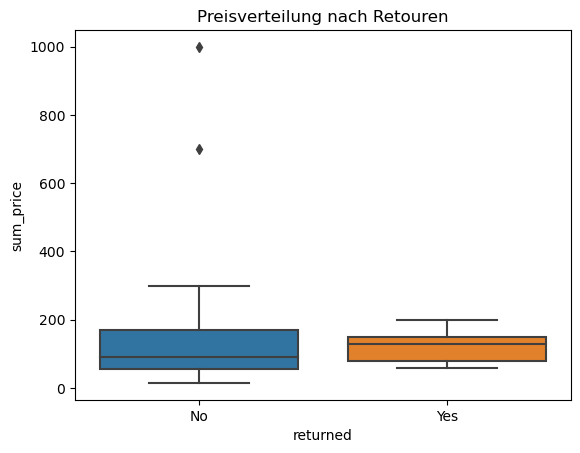

In [33]:
sns.boxplot(x="returned", y="sum_price", data=df2)
plt.title("Preisverteilung nach Retouren")
plt.show()

In [35]:
# statistischer Test

from scipy.stats import ttest_ind

# Preis für retourniert vs. nicht retourniert
returned_prices = df2[df2["returned_num"] == 1]["sum_price"]
not_returned_prices = df2[df2["returned_num"] == 0]["sum_price"]

t_stat, p_value = ttest_ind(returned_prices, not_returned_prices)
print(t_stat, p_value)

-0.6031083260546449 0.5539606731195469


## 5. Versand & Logistik
### Wie wirkt sich die Lieferzeit auf Retouren aus?


In [36]:
df.head()

,order_id,customer_id,order_date,product_category,product_name,price,quantity,payment_method,country,shipping_time_days,returned,returned_num,sum_price
0,1001,C001,2025-01-05,Electronics,Wireless Mouse,25.99,2,Credit Card,Germany,3,No,0,51.98
1,1002,C002,2025-01-07,Clothing,T-Shirt,15.00,1,PayPal,Germany,5,No,0,15.00
2,1003,C003,2025-01-08,Electronics,Headphones,79.99,1,Credit Card,France,4,Yes,1,79.99
3,1004,C001,2025-01-10,Home,Blender,49.99,1,Klarna,Germany,6,No,0,49.99
4,1005,C004,2025-01-11,Clothing,Jeans,60.00,1,PayPal,Spain,7,Yes,1,60.00


In [ ]:
# Korrelation berechnen

df2[["shipping_time_days", "returned_num"]].corr()

,shipping_time_days,returned_num
shipping_time_days,1.000000,0.282617
returned_num,0.282617,1.000000


In [39]:
# durchschnittliche Lieferzeit

df2.groupby("returned")["shipping_time_days"].mean()

returned
No     4.2
Yes    5.2
Name: shipping_time_days, dtype: float64

In [40]:
from scipy.stats import ttest_ind

returned_times = df2[df2["returned_num"] == 1]["shipping_time_days"]
not_returned_times = df2[df2["returned_num"] == 0]["shipping_time_days"]

t_stat, p_value = ttest_ind(returned_times, not_returned_times)
print(t_stat, p_value)

1.25 0.2273077238444224


kein signifikanter Unterschied.

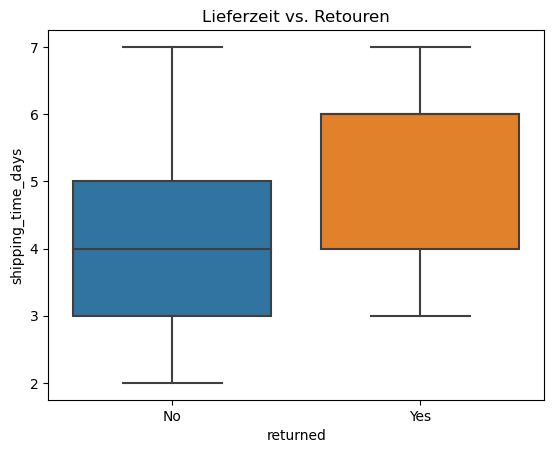

In [ ]:
sns.boxplot(x="returned", y="shipping_time_days", data=df2)
plt.title("Lieferzeit vs. Retouren")
plt.show()

In [ ]:
# logistic regression

import statsmodels.api as sm

X = df2[["shipping_time_days"]]   
y = df2["returned_num"]       

X = sm.add_constant(X)       
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.521152
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           returned_num   No. Observations:                   20
Model:                          Logit   Df Residuals:                       18
Method:                           MLE   Df Model:                            1
Date:                Mon, 23 Mar 2026   Pseudo R-squ.:                 0.07324
Time:                        10:08:15   Log-Likelihood:                -10.423
converged:                       True   LL-Null:                       -11.247
Covariance Type:            nonrobust   LLR p-value:                    0.1993
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -3.2406      1.928     -1.681      0.093      -7.019       0.537
shipp

### Haben bestimmte Länder längere Lieferzeiten?

In [ ]:
# durchschnittliche Lieferzeit pro Land

df.groupby("country")["shipping_time_days"].mean().sort_values(ascending=False)

country
Spain      6.666667
France     4.750000
Italy      4.000000
Germany    3.818182
Name: shipping_time_days, dtype: float64

In [53]:
# median robuster 
df.groupby("country")["shipping_time_days"].median().sort_values(ascending=False)

country
Spain      7.0
France     5.0
Germany    4.0
Italy      4.0
Name: shipping_time_days, dtype: float64

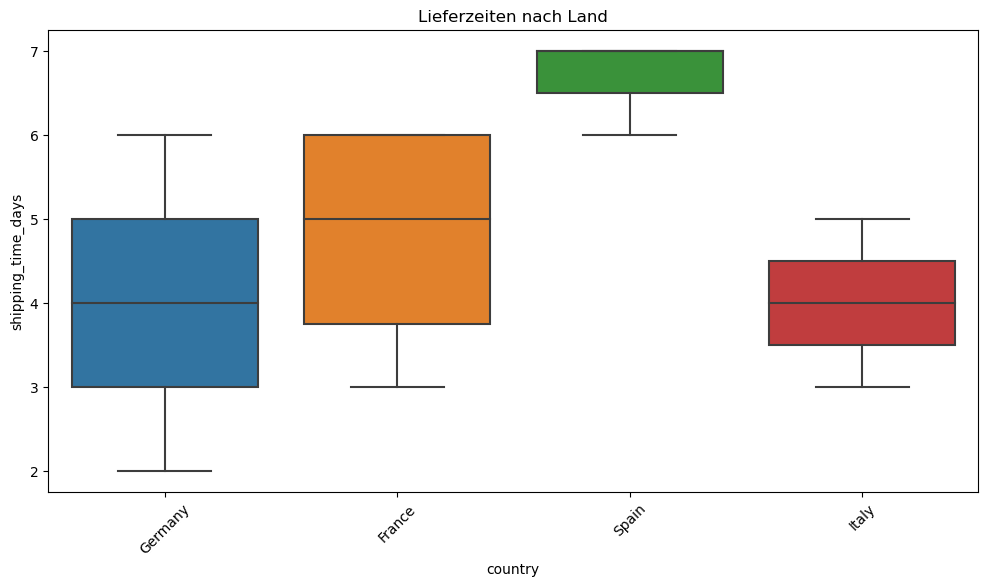

In [54]:
plt.figure(figsize=(12,6))
sns.boxplot(x="country", y="shipping_time_days", data=df)
plt.xticks(rotation=45)
plt.title("Lieferzeiten nach Land")
plt.show()

In [55]:
from scipy.stats import f_oneway

groups = [df2[df2["country"] == c]["shipping_time_days"] for c in df2["country"].unique()]
f_stat, p_value = f_oneway(*groups)
print(f_stat, p_value)

3.922561374031552 0.028288987111550618


### Gibt es einen Zusammenhang zwischen schneller Lieferung und höherem Umsatz?

In [56]:
df2[["shipping_time_days", "sum_price"]].corr()

,shipping_time_days,sum_price
shipping_time_days,1.000000,-0.589538
sum_price,-0.589538,1.000000


In [ ]:
# schnelle Lieferungen = <= 3 Tage
# zeigt ob schnellere Lieferungen im Schnitt höheren Umsatz bringen
# 1 schnell, 0 langsam

df2["fast_delivery"] = (df2["shipping_time_days"] <= 3).astype(int)

df2.groupby("fast_delivery")["sum_price"].mean()

fast_delivery
0     86.151538
1    359.210000
Name: sum_price, dtype: float64

In [ ]:
fast = df2[df2["fast_delivery"] == 1]["sum_price"]
slow = df2[df2["fast_delivery"] == 0]["sum_price"]

t_stat, p_value = ttest_ind(fast, slow)
print(t_stat, p_value)

# es gibt einen signifikanten Unterschied im Umsatz zwischen schneller und langsamer Lieferung

2.793888175398921 0.011992724516286692


In [ ]:
# Regression für den Zusammenhang
# Um kontinuierliche Lieferzeit gegen Umsatz zu testen

X = df2[["shipping_time_days"]]  
y = df2["sum_price"]       

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              sum_price   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     9.589
Date:                Mon, 23 Mar 2026   Prob (F-statistic):            0.00623
Time:                        10:33:04   Log-Likelihood:                -133.45
No. Observations:                  20   AIC:                             270.9
Df Residuals:                      18   BIC:                             272.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                587.1978    138

## 6. Zahlungsarten
### Welche Zahlungsmethode wird am häufigsten genutzt?


In [60]:
df.head()

,order_id,customer_id,order_date,product_category,product_name,price,quantity,payment_method,country,shipping_time_days,returned,returned_num,sum_price,fast_delivery
0,1001,C001,2025-01-05,Electronics,Wireless Mouse,25.99,2,Credit Card,Germany,3,No,0,51.98,1
1,1002,C002,2025-01-07,Clothing,T-Shirt,15.00,1,PayPal,Germany,5,No,0,15.00,0
2,1003,C003,2025-01-08,Electronics,Headphones,79.99,1,Credit Card,France,4,Yes,1,79.99,0
3,1004,C001,2025-01-10,Home,Blender,49.99,1,Klarna,Germany,6,No,0,49.99,0
4,1005,C004,2025-01-11,Clothing,Jeans,60.00,1,PayPal,Spain,7,Yes,1,60.00,0


In [62]:
df.groupby("payment_method")["order_id"].count()

payment_method
Credit Card    10
Klarna          4
PayPal          6
Name: order_id, dtype: int64

### Gibt es Unterschiede in Retouren je Zahlungsart?

In [63]:
return_by_payment = df2.groupby("payment_method")["returned_num"].mean().sort_values(ascending=False)
return_by_payment

payment_method
PayPal         0.50
Klarna         0.25
Credit Card    0.10
Name: returned_num, dtype: float64

In [64]:
orders_by_payment = df2.groupby("payment_method")["order_id"].count()
orders_by_payment

payment_method
Credit Card    10
Klarna          4
PayPal          6
Name: order_id, dtype: int64

In [65]:
analysis = df2.groupby("payment_method").agg({
    "returned_num": "mean",
    "order_id": "count"
}).rename(columns={"returned_num": "return_rate", "order_id": "num_orders"})

analysis.sort_values("return_rate", ascending=False)

,return_rate,num_orders
payment_method,,
PayPal,0.50,6
Klarna,0.25,4
Credit Card,0.10,10


In [ ]:
from scipy.stats import chi2_contingency

# Kreuztabelle Zahlungsart vs. Retouren
contingency = pd.crosstab(df2["payment_method"], df2["returned_num"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi²-Statistik:", chi2)
print("p-Wert:", p) # kein signifikanter Unterschied

Chi²-Statistik: 3.2
p-Wert: 0.2018965179946554


In [70]:
# Retourenrate und Anzahl Bestellungen pro Zahlungsart
analysis = df2.groupby("payment_method").agg({
    "returned_num": "mean",  # Durchschnitt = Retourenrate
    "order_id": "count"       # Anzahl Bestellungen
}).rename(columns={"returned_num": "return_rate", "order_id": "num_orders"}).reset_index()

analysis

,payment_method,return_rate,num_orders
0,Credit Card,0.10,10
1,Klarna,0.25,4
2,PayPal,0.50,6


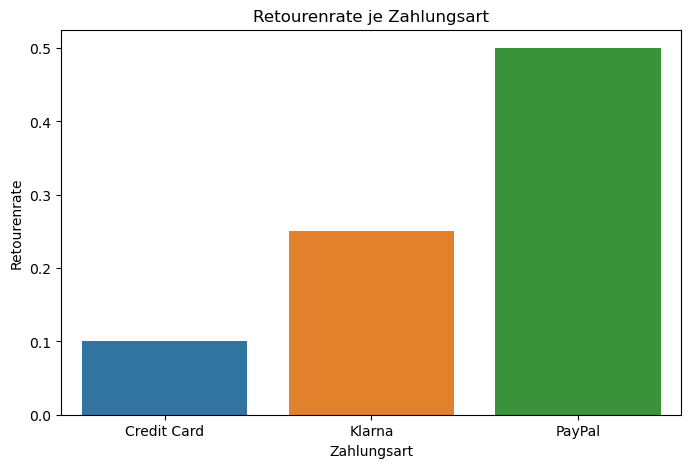

In [72]:
plt.figure(figsize=(8,5))
sns.barplot(x="payment_method", y="return_rate", data=analysis)
plt.title("Retourenrate je Zahlungsart")
plt.ylabel("Retourenrate")
plt.xlabel("Zahlungsart")
plt.show()